In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

#### Get the flood dataset

In [3]:
# MERGED TWICE TO REMOVE DUPLICATES

flood_county = pd.read_csv(
    "../../02_processed_data/fema_flood_county_2000.csv"
).reset_index(drop=True)
flood_county.sort_values(by=["FIPS", "YEAR"]).dropna()
print(flood_county.info())
print(flood_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35450 entries, 0 to 35449
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FIPS                   35450 non-null  int64  
 1   YEAR                   35450 non-null  int64  
 2   STATE                  35450 non-null  object 
 3   CZ_NAME                35450 non-null  object 
 4   COUNT                  35450 non-null  int64  
 5   TOTAL_DAMAGE_PROPERTY  35450 non-null  float64
 6   TOTAL_DURATION_HOURS   35450 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.9+ MB
None
               FIPS          YEAR         COUNT  TOTAL_DAMAGE_PROPERTY  \
count  35450.000000  35450.000000  35450.000000           3.545000e+04   
mean   30434.366008   2010.019069     13.039126           3.367555e+06   
std    14880.622613      6.061159     18.316309           1.256051e+08   
min     1001.000000   2000.000000      1.000000           0.0

#### Get the HPI dataset

In [5]:
hpi_county = pd.read_csv("../../02_processed_data/hpi_county_2000.csv")
hpi_county.sort_values(by=["county_fips5", "yr"]).dropna()
print(hpi_county.info())
print(hpi_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21965 entries, 0 to 21964
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cbsa_code                 21965 non-null  int64  
 1   cbsa_title                21965 non-null  object 
 2   county_fips5              21965 non-null  int64  
 3   county/county_equivalent  21965 non-null  object 
 4   state_name                21965 non-null  object 
 5   place_name                21965 non-null  object 
 6   place_id                  21965 non-null  int64  
 7   yr                        21965 non-null  int64  
 8   index_nsa                 21965 non-null  float64
 9   index_prev                21965 non-null  float64
 10  hpi_change                21965 non-null  float64
 11  hpi_yoy                   21965 non-null  float64
dtypes: float64(4), int64(4), object(4)
memory usage: 2.0+ MB
None
          cbsa_code  county_fips5      place_id       

#### Checking for missing counties

In [7]:
# hpi_county[hpi_county["cbsa_code"] == "10100"]
flood_county[flood_county["FIPS"] == "46045"]

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS


In [8]:
min(hpi_county["county_fips5"]), max(hpi_county["county_fips5"])

(1001, 56025)

In [9]:
mask = ~hpi_county["county_fips5"].isin(flood_county["FIPS"])
hpi_no_flood = hpi_county.loc[mask, "county_fips5"].unique()
hpi_no_flood

array([ 2170, 41031,  9120,  9190,  2090,  9110,  9130, 15005,  9170,
        9180, 53059, 13173,  9140])

In [10]:
mask = ~flood_county["FIPS"].isin(hpi_county["county_fips5"])
flood_no_hpi = flood_county.loc[mask, "FIPS"].unique()
flood_no_hpi

array([ 1005,  1011,  1013, ..., 56041, 56043, 56045])

#### Merge flood and HPI datasets

In [12]:
hpi_flood = pd.merge(
    hpi_county[["county_fips5", "yr", "hpi_yoy"]],
    flood_county,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "YEAR"],
    how="left",
)

# Identify columns that came from flood_county (excluding join keys)
flood_cols = [c for c in flood_county.columns if c not in ["FIPS", "YEAR"]]

# Impute those flood variables as 0
hpi_flood[flood_cols] = hpi_flood[flood_cols].fillna(0)

# Drop join-key duplicates from the merged df
hpi_flood = hpi_flood.drop(columns=["FIPS", "YEAR"])

hpi_flood.head()

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,48059,2000,1.226954,0,0,0.0,0.0,0.00
1,48059,2001,4.070521,0,0,0.0,0.0,0.00
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18


In [13]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Get heat dataset

In [15]:
heat_county = pd.read_csv(
    "../../02_processed_data/county_heat_index_2000_2020_with_HSI.csv"
).reset_index(drop=True)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the fIPS codes for states

In [17]:
us_states_fips = pd.read_csv("../../01_original_data/us_states_fips.csv").reset_index(
    drop=True
)
us_states_fips.head()

,state,fips,longname
0,AL,1,Alabama
1,AK,2,Alaska
2,AZ,4,Arizona
3,AR,5,Arkansas
4,CA,6,California


#### Create FIPS codes in heat dataset

In [19]:
def process_fips(heat_county):
    county_split = str(heat_county).split("-")
    state = str(
        us_states_fips[us_states_fips["state"] == county_split[0]]["fips"].values[0]
    ).zfill(2)
    county = county_split[1]
    return state + county


heat_county["FIPS"] = heat_county["id"].apply(lambda x: process_fips(x))
heat_county["FIPS"] = heat_county["FIPS"].astype(int)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI,FIPS
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615,1001
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779,1001
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973,1001
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611,1001
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037


In [20]:
# CHECKING FOR DUPLICATES
temp = (
    heat_county.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Merge heat and HPI/flood datasets

In [22]:
hpi_flood_heat = pd.merge(
    hpi_flood,
    heat_county[["FIPS", "year", "value", "heat_index", "HSI"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Identify columns that came from heat_county, excluding join keys
heat_cols = ["FIPS", "year", "value", "heat_index", "HSI"]

# Impute only heat-related variables as 0
hpi_flood_heat[heat_cols] = hpi_flood_heat[heat_cols].fillna(0)

# Drop join-key duplicates
hpi_flood_heat = hpi_flood_heat.drop(columns=["FIPS", "year"])

hpi_flood_heat.head()
hpi_flood_heat

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233
...,...,...,...,...,...,...,...,...,...,...,...
21960,4027,2016,3.794342,ARIZONA,YUMA,3.0,0.0,3.00,106.9,0.414770,0.872492
21961,4027,2017,3.854183,0,0,0.0,0.0,0.00,107.2,0.419574,0.878639
21962,4027,2018,3.642268,ARIZONA,YUMA,7.0,65000.0,17.83,106.4,0.402691,0.818690
21963,4027,2019,5.189345,ARIZONA,YUMA,2.0,2000.0,7.87,106.7,0.410549,0.944888


In [23]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge the drought and wildfire datasets

In [25]:
drought_county = pd.read_csv(
    "../../02_processed_data/NCEI_annual_drought_county_FINAL.csv"
).reset_index(drop=True)
drought_county = drought_county[drought_county["FIPS"] != 0]
drought_county.sort_values(by=["FIPS", "Year"]).dropna()
drought_county = drought_county.drop(["County", "State", "State_abbr"], axis=1)

In [26]:
dupes = drought_county[drought_county.duplicated(subset=["FIPS", "Year"], keep=False)]
dupes = dupes.sort_values(by=["FIPS", "Year"])
drought_county = drought_county.drop_duplicates(subset=["FIPS", "Year"], keep="first")
drought_county.head()

,FIPS,Year,Annual_Mean_Index
0,1001,2000,-2.32
1,1001,2001,1.43
2,1001,2002,-0.76
3,1001,2003,2.39
4,1001,2004,0.00


In [27]:
drought_hpi_flood_heat = pd.merge(
    hpi_flood_heat,
    drought_county[["FIPS", "Year", "Annual_Mean_Index"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

drought_hpi_flood_heat = drought_hpi_flood_heat.drop(columns=["FIPS", "Year"])

drought_hpi_flood_heat["Annual_Mean_Index"] = drought_hpi_flood_heat["Annual_Mean_Index"].fillna(0)

drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28


In [28]:
# CHECKING FOR DUPLICATES
temp = (
    drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


In [29]:
wildfire_county = pd.read_csv(
    "../../02_processed_data/wildfire_data_preprocessed.csv"
).reset_index(drop=True)
wildfire_county.sort_values(by=["FIPS", "Year"]).dropna()
wildfire_county = wildfire_county.drop(["State"], axis=1)
wildfire_county.head()

,FIPS,Year,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,1001,2003,43,274.8
1,1001,2004,86,744.5
2,1001,2005,63,234.2
3,1001,2006,62,534.7
4,1001,2007,93,477.3


In [30]:
wildfire_drought_hpi_flood_heat = pd.merge(
    drought_hpi_flood_heat,
    wildfire_county[["FIPS", "Year", "FIRE_FREQUENCY", "TOTAL_FIRE_SIZE"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

wildfire_drought_hpi_flood_heat = wildfire_drought_hpi_flood_heat.drop(columns=["FIPS", "Year"])

wildfire_drought_hpi_flood_heat["FIRE_FREQUENCY"] = wildfire_drought_hpi_flood_heat["FIRE_FREQUENCY"].fillna(0)
wildfire_drought_hpi_flood_heat["TOTAL_FIRE_SIZE"] = wildfire_drought_hpi_flood_heat["TOTAL_FIRE_SIZE"].fillna(0)

wildfire_drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36,0.0,0.0
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39,0.0,0.0
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54,0.0,0.0
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96,1.0,100.0
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19.0,61.0


In [31]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge Drought/Wildfire/HPI/Flood/Heat/Hurricane datasets

In [33]:
storm_summary = pd.read_csv(
    "../../02_processed_data/storm_data_aggregated_county.csv", low_memory=False
)
storm_summary["year"] = storm_summary["year"].astype("int")
storm_summary["FIPS"] = storm_summary["FIPS"].astype("int")

huricane_grouped = storm_summary.groupby(["FIPS", "year"], as_index=False).agg(
    deaths_hurricane=("deaths", "sum"),
    injuries_hurricane=("injuries", "sum"),
    damage_hurricane=("damage", "sum"),
)

huricane_grouped.sort_values(by=["FIPS", "year"])

,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,1003,2002,0.0,0.0,75000
1,1003,2004,0.0,0.0,0
2,1003,2005,0.0,0.0,0
3,1003,2020,2.0,0.0,236080000
4,1013,2004,0.0,0.0,0
...,...,...,...,...,...
947,51730,2003,1.0,0.0,9700000
948,51740,2003,0.0,0.0,10000000
949,51800,2003,0.0,0.0,33000000
950,51810,2003,0.0,0.0,39400000


In [34]:
wildfire_drought_hpi_flood_heat_huricane = pd.merge(
    wildfire_drought_hpi_flood_heat,
    huricane_grouped,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Columns coming from huricane_grouped, excluding join keys
hurricane_cols = [c for c in huricane_grouped.columns if c not in ["FIPS", "year"]]

# Impute only hurricane variables as 0
wildfire_drought_hpi_flood_heat_huricane[hurricane_cols] = (
    wildfire_drought_hpi_flood_heat_huricane[hurricane_cols].fillna(0)
)


wildfire_drought_hpi_flood_heat_huricane

,county_fips5,yr,hpi_yoy,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,48059,2000,1.226954,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36,0.0,0.00,NaN,NaN,0.0,0.0,0.0
1,48059,2001,4.070521,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39,0.0,0.00,NaN,NaN,0.0,0.0,0.0
2,48059,2002,2.850440,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54,0.0,0.00,NaN,NaN,0.0,0.0,0.0
3,48059,2003,2.620052,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96,1.0,100.00,NaN,NaN,0.0,0.0,0.0
4,48059,2004,4.455241,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19.0,61.00,NaN,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21960,4027,2016,3.794342,ARIZONA,YUMA,3.0,0.0,3.00,106.9,0.414770,0.872492,-2.68,11.0,1326.60,NaN,NaN,0.0,0.0,0.0
21961,4027,2017,3.854183,0,0,0.0,0.0,0.00,107.2,0.419574,0.878639,-2.05,17.0,103.00,NaN,NaN,0.0,0.0,0.0
21962,4027,2018,3.642268,ARIZONA,YUMA,7.0,65000.0,17.83,106.4,0.402691,0.818690,-2.95,191.0,594.87,NaN,NaN,0.0,0.0,0.0
21963,4027,2019,5.189345,ARIZONA,YUMA,2.0,2000.0,7.87,106.7,0.410549,0.944888,-0.23,64.0,1265.91,NaN,NaN,0.0,0.0,0.0


In [35]:
df = wildfire_drought_hpi_flood_heat_huricane

# columns to drop
cols_to_drop = ["YEAR", "year_y", "State_fire", "State_ncei", "State_abbr", "Year", "county_fips5", "year_x", "FIPS", "year"]

# drop them from df (ignore any that might be missing)
df = df.drop(columns=cols_to_drop, errors="ignore")

# quick check
print(df.columns)
print(df.info())
print(df.describe())

Index(['yr', 'hpi_yoy', 'STATE', 'CZ_NAME', 'COUNT', 'TOTAL_DAMAGE_PROPERTY',
       'TOTAL_DURATION_HOURS', 'value', 'heat_index', 'HSI',
       'Annual_Mean_Index', 'FIRE_FREQUENCY', 'TOTAL_FIRE_SIZE',
       'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21965 entries, 0 to 21964
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     21965 non-null  int64  
 1   hpi_yoy                21965 non-null  float64
 2   STATE                  21965 non-null  object 
 3   CZ_NAME                21965 non-null  object 
 4   COUNT                  21965 non-null  float64
 5   TOTAL_DAMAGE_PROPERTY  21965 non-null  float64
 6   TOTAL_DURATION_HOURS   21965 non-null  float64
 7   value                  21965 non-null  float64
 8   heat_index             21965 non-null  float64
 9   HSI               

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [37]:
df = df.rename(
    columns={
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        # "HSI": "HEAT_HSI",
    }
)
df.columns

Index(['yr', 'hpi_yoy', 'STATE', 'CZ_NAME', 'FLOOD_FREQUENCY',
       'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_VALUE',
       'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY',
       'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane'],
      dtype='object')

## OLS Regression

Index(['yr', 'hpi_yoy', 'STATE', 'CZ_NAME', 'FLOOD_FREQUENCY',
       'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_VALUE',
       'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY',
       'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane'],
      dtype='object')

Numeric predictors used:
['yr', 'FLOOD_FREQUENCY', 'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_VALUE', 'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY', 'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane']

=== OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:                hpi_yoy   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     26.39
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           7.60e-65
Time: 

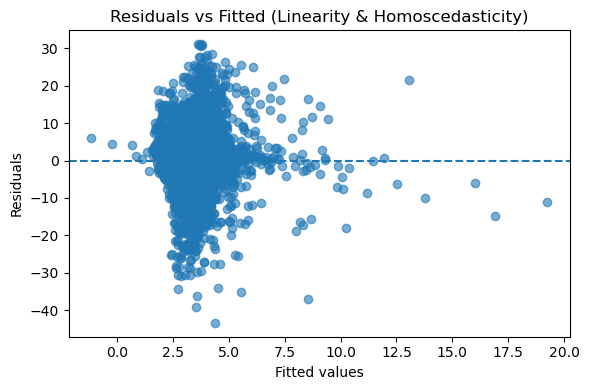

/var/folders/26/4y4fzxhd7td390hxfyvrnw1m0000gp/T/ipykernel_16106/239519526.py:92: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


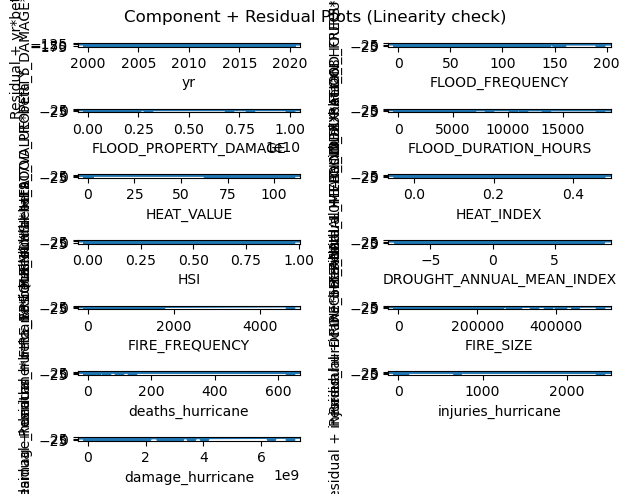


Durbin–Watson statistic: 0.481


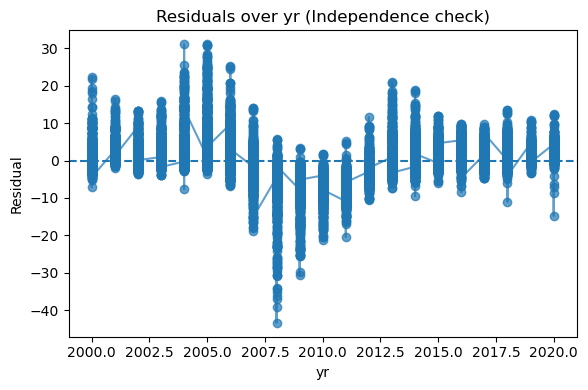

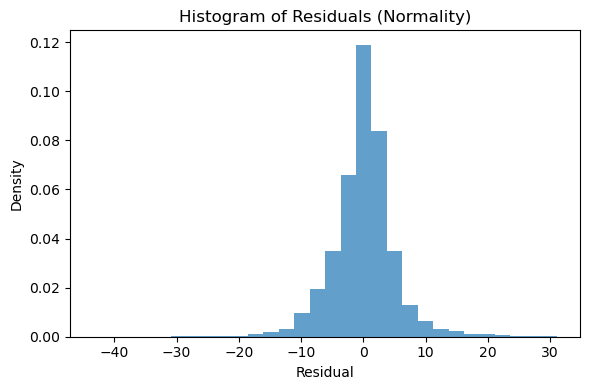

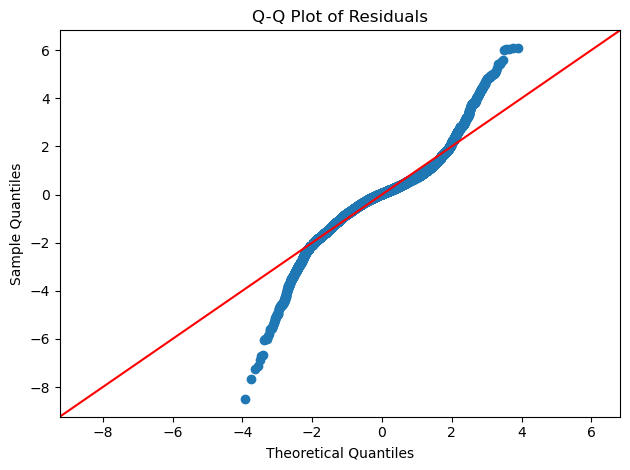


Shapiro–Wilk: stat=0.936, p=3.71e-69
Jarque–Bera: stat=23467.251, p=0, skew=-0.115, kurtosis=8.058


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 21965.
  res = hypotest_fun_out(*samples, **kwds)


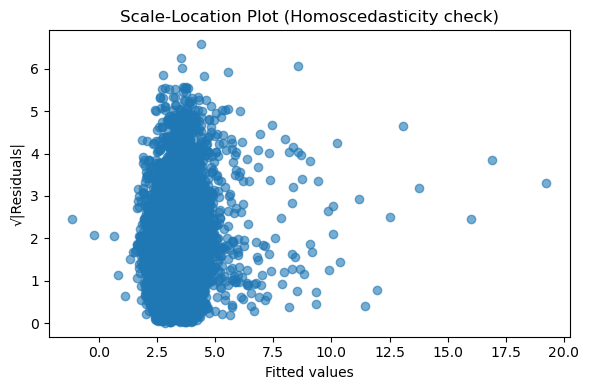

X_exog shape for BP: (21965, 14)

Breusch–Pagan test: LM stat=1330.064, p=1.78e-276, F=108.838, F p=2.11e-285


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tools.tools import fullrank
from scipy import stats

# -------------------------------------------
# 0. Start from your merged dataframe
# -------------------------------------------
df = wildfire_drought_hpi_flood_heat_huricane

# columns to drop (join keys / IDs / duplicates)
cols_to_drop = [
    "YEAR", "year_y", "State_fire", "State_ncei",
    "State_abbr", "Year", "county_fips5",
    "year_x", "FIPS", "year"
]
df = df.drop(columns=cols_to_drop, errors="ignore")

# rename for cleaner names
df = df.rename(
    columns={
        "HPI_YoY": "hpi_yoy",
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
    }
)

print(df.columns)

# -------------------------------------------
# 1. Build X and y
# -------------------------------------------
target = "hpi_yoy"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = [target]  # response only; FIPS is already dropped

predictors = [c for c in numeric_cols if c not in exclude_cols]
print("\nNumeric predictors used:")
print(predictors)

X = df[predictors].copy()
y = df[target]

# Drop any constant or duplicate columns just to be safe
constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    X = X.drop(columns=constant_cols)

dup_mask = X.T.duplicated()
if dup_mask.any():
    print("Dropping duplicate columns:", list(X.columns[dup_mask]))
    X = X.loc[:, ~dup_mask]

# Add intercept
X = sm.add_constant(X)

# -------------------------------------------
# 2. Fit OLS
# -------------------------------------------
model = sm.OLS(y, X, missing="drop").fit()
print("\n=== OLS Summary ===")
print(model.summary())

resid = model.resid
fitted = model.fittedvalues

# -------------------------------------------
# 3. L – Linearity
# -------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linearity & Homoscedasticity)")
plt.tight_layout()
plt.show()

fig = sm.graphics.plot_ccpr_grid(model)
fig.suptitle("Component + Residual Plots (Linearity check)", y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 4. I – Independence
# -------------------------------------------
dw = durbin_watson(resid)
print(f"\nDurbin–Watson statistic: {dw:.3f}")

# If 'yr' is still in df, use it as time variable
if "yr" in df.columns:
    temp = pd.DataFrame({"yr": df["yr"], "resid": resid}).dropna()
    temp = temp.sort_values(by="yr")
    plt.figure(figsize=(6, 4))
    plt.plot(temp["yr"], temp["resid"], marker="o", linestyle="-", alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("yr")
    plt.ylabel("Residual")
    plt.title("Residuals over yr (Independence check)")
    plt.tight_layout()
    plt.show()

# -------------------------------------------
# 5. N – Normality
# -------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30, density=True, alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Histogram of Residuals (Normality)")
plt.tight_layout()
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"\nShapiro–Wilk: stat={shapiro_stat:.3f}, p={shapiro_p:.3g}")

jb_stat, jb_p, skew, kurt = sm.stats.jarque_bera(resid)
print(f"Jarque–Bera: stat={jb_stat:.3f}, p={jb_p:.3g}, skew={skew:.3f}, kurtosis={kurt:.3f}")

from statsmodels.tools.tools import fullrank

# ---------------------------------------------------
# 7. E – Equal variance (Scale-location + Breusch–Pagan)
# ---------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot (Homoscedasticity check)")
plt.tight_layout()
plt.show()

X_exog = model.model.exog
print("X_exog shape for BP:", X_exog.shape)

# Only run BP if we have constant + at least 1 predictor
if X_exog.shape[1] < 2:
    print("\nNot enough predictors to run Breusch–Pagan test (need constant + at least 1 covariate).")
else:
    bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(resid, X_exog)
    print(f"\nBreusch–Pagan test: LM stat={bp_stat:.3f}, p={bp_p:.3g}, "
          f"F={bp_f:.3f}, F p={bp_f_p:.3g}")

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[[
    'FLOOD_FREQUENCY', 'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS',
    'HEAT_VALUE', 'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX',
    'FIRE_FREQUENCY', 'FIRE_SIZE', 'deaths_hurricane',
    'injuries_hurricane', 'damage_hurricane'
]]

# Standardize or just keep as-is
vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_df)

                     variable        VIF
0             FLOOD_FREQUENCY   1.346945
1       FLOOD_PROPERTY_DAMAGE   1.002903
2        FLOOD_DURATION_HOURS   1.080269
3                  HEAT_VALUE  14.524953
4                  HEAT_INDEX   5.704807
5                         HSI  15.057570
6   DROUGHT_ANNUAL_MEAN_INDEX   1.463935
7              FIRE_FREQUENCY   1.230417
8                   FIRE_SIZE   1.055303
9            deaths_hurricane   1.149077
10         injuries_hurricane   1.042307
11           damage_hurricane   1.195855


## Ridge Regression

In [42]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

X_ridge = df[predictors].copy()
y_ridge = df[target].copy()

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
)

ridge_cv.fit(X_ridge, y_ridge)

ridge_step = ridge_cv.named_steps["ridgecv"]
print("Chosen alpha:", ridge_step.alpha_)

y_pred_ridge = ridge_cv.predict(X_ridge)
print("Ridge MSE:", mean_squared_error(y_ridge, y_pred_ridge))
print("Ridge R^2:", r2_score(y_ridge, y_pred_ridge))

# Coefficients on standardized scale:
for name, coef in zip(predictors, ridge_step.coef_):
    print(f"{name:30s} {coef: .4f}")

Chosen alpha: 100.0
Ridge MSE: 25.97063595602957
Ridge R^2: 0.015388868518623533
yr                             -0.4543
FLOOD_FREQUENCY                -0.1004
FLOOD_PROPERTY_DAMAGE           0.0057
FLOOD_DURATION_HOURS           -0.0807
HEAT_VALUE                     -0.0114
HEAT_INDEX                      0.1697
HSI                            -0.1346
DROUGHT_ANNUAL_MEAN_INDEX       0.3636
FIRE_FREQUENCY                  0.2777
FIRE_SIZE                       0.2471
deaths_hurricane               -0.0196
injuries_hurricane             -0.0242
damage_hurricane                0.2102


## ar(1)

     yr   hpi_yoy
0  2000  1.226954
1  2001  4.070521
2  2002  2.850440
3  2003  2.620052
4  2004  4.455241
yr
2000    4.509167
2001    5.881094
2002    4.767851
2003    5.167268
2004    7.155412
Name: hpi_yoy, dtype: float64


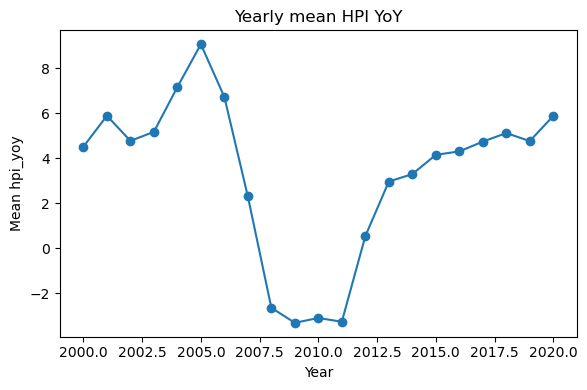

In [44]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# starting from your cleaned df
# it must have columns: 'yr' and 'hpi_yoy'
print(df[['yr', 'hpi_yoy']].head())

# 1) aggregate to yearly mean HPI YoY across counties
hpi_yearly = (
    df.groupby('yr', as_index=True)['hpi_yoy']
      .mean()
      .sort_index()
)

print(hpi_yearly.head())

# quick plot
plt.figure(figsize=(6,4))
hpi_yearly.plot(marker='o')
plt.title("Yearly mean HPI YoY")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.tight_layout()
plt.show()


In [45]:
from statsmodels.tsa.arima.model import ARIMA

# AR(1) ≡ ARIMA(p=1, d=0, q=0)
ar1_model = ARIMA(hpi_yearly, order=(1, 0, 0)).fit()

print(ar1_model.summary())


                               SARIMAX Results                                
Dep. Variable:                hpi_yoy   No. Observations:                   21
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -44.113
Date:                Wed, 03 Dec 2025   AIC                             94.225
Time:                        21:48:10   BIC                             97.359
Sample:                             0   HQIC                            94.905
                                 - 21                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8489      2.998      1.284      0.199      -2.028       9.725
ar.L1          0.8153      0.118      6.887      0.000       0.583       1.047
sigma2         3.7109      1.237      2.999      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


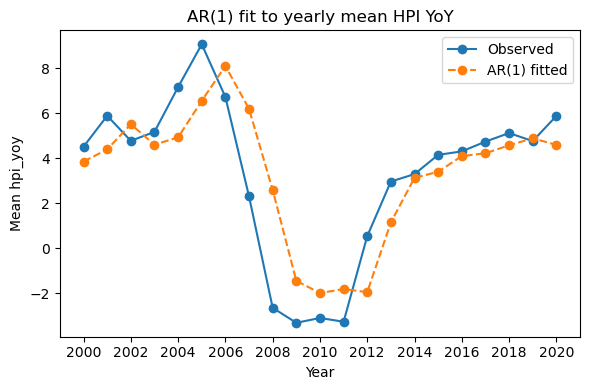

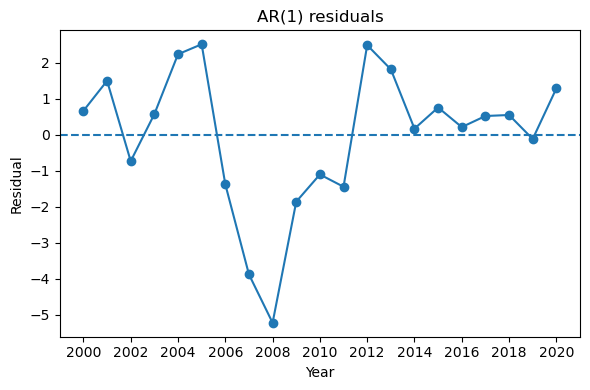

In [46]:
# Fitted values (in-sample)
fitted_ar1 = ar1_model.fittedvalues

plt.figure(figsize=(6,4))
plt.plot(hpi_yearly.index, hpi_yearly, marker='o', label="Observed")
plt.plot(hpi_yearly.index, fitted_ar1, marker='o', linestyle='--', label="AR(1) fitted")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.title("AR(1) fit to yearly mean HPI YoY")
plt.legend()
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

# Residuals
resid_ar1 = ar1_model.resid

plt.figure(figsize=(6,4))
plt.plot(hpi_yearly.index, resid_ar1, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel("Year")
plt.ylabel("Residual")
plt.title("AR(1) residuals")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()


#### We aggregated county-level HPI growth to yearly means and fit an AR(1) model, $Y_t = c + \phi_1 Y_{t-1} + \varepsilon_t$. The estimated AR coefficient $\hat{\phi}_1 = 0.82$ ($p < 0.001$) indicates strong persistence in annual HPI growth: high-growth years tend to be followed by high growth in the next year. The model captures the broad rise, crash around 2008--2011, and subsequent recovery, but residuals remain large during the crash period, reflecting shocks that are not well captured by a simple AR(1) structure.


## add other predictors on AR(1) model with PCA

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Define hazard predictors (excluding year and HPI target)
exog_vars = [
    'FLOOD_FREQUENCY',
    'FLOOD_PROPERTY_DAMAGE',
    'FLOOD_DURATION_HOURS',
    'HEAT_VALUE',
    'HEAT_INDEX',
    'HSI',
    'DROUGHT_ANNUAL_MEAN_INDEX',
    'FIRE_FREQUENCY',
    'FIRE_SIZE',
    'deaths_hurricane',
    'injuries_hurricane',
    'damage_hurricane'
]

# Aggregate to yearly means
yearly = (
    df.groupby('yr')[['hpi_yoy'] + exog_vars]
      .mean()
      .sort_index()
)

# PCA on all exogenous hazard predictors
X_raw = yearly[exog_vars]
X_scaled = StandardScaler().fit_transform(X_raw)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

print(f"Keep {pca.n_components_} principal components")

# Add PCs back to dataframe
for i in range(pca.n_components_):
    yearly[f"PC{i+1}"] = X_pca[:, i]

# Define target and predictors for ARIMA
y_ts = yearly["hpi_yoy"]
X_ts = yearly[[f"PC{i+1}" for i in range(pca.n_components_)]]

Keep 6 principal components


In [50]:
# AR(1) with exogenous regressors
ar1_x_model = ARIMA(endog=y_ts, exog=X_ts, order=(1, 0, 0)).fit()
print(ar1_x_model.summary())

                               SARIMAX Results                                
Dep. Variable:                hpi_yoy   No. Observations:                   21
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -40.343
Date:                Wed, 03 Dec 2025   AIC                             98.686
Time:                        21:48:10   BIC                            108.087
Sample:                             0   HQIC                           100.726
                                 - 21                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6787      3.677      1.000      0.317      -3.529      10.886
PC1           -0.1003      0.444     -0.226      0.821      -0.970       0.769
PC2           -0.1131      0.688     -0.164      0.8

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


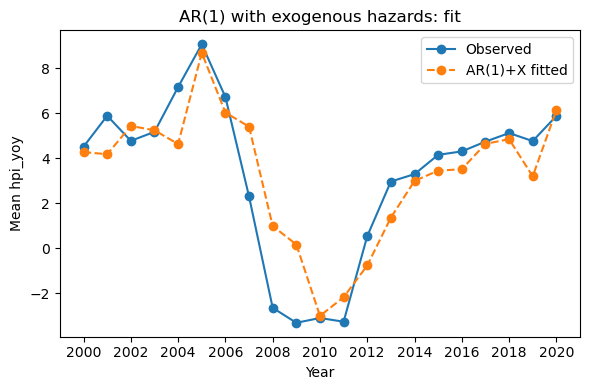

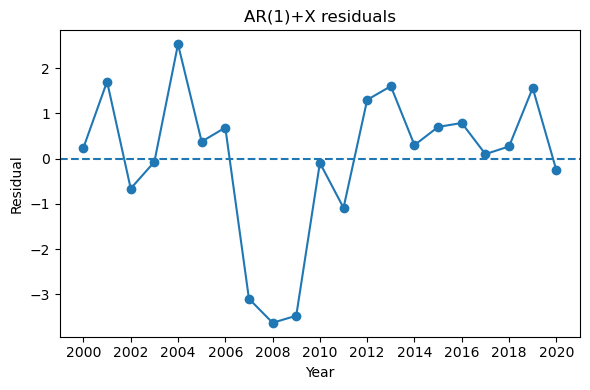

In [51]:
# In-sample fitted values
fitted_ar1x = ar1_x_model.fittedvalues

plt.figure(figsize=(6,4))
plt.plot(y_ts.index, y_ts, marker='o', label='Observed')
plt.plot(y_ts.index, fitted_ar1x, marker='o', linestyle='--', label='AR(1)+X fitted')
plt.xlabel('Year')
plt.ylabel('Mean hpi_yoy')
plt.title('AR(1) with exogenous hazards: fit')
plt.legend()
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

# Residuals
resid_ar1x = ar1_x_model.resid

plt.figure(figsize=(6,4))
plt.plot(y_ts.index, resid_ar1x, marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.title('AR(1)+X residuals')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

#### We extended the AR(1) model for yearly mean HPI growth to include exogenous measures of flood, heat, drought, fire, and hurricane hazards (ARIMAX(1,0,0)). While the exogenous terms largely removed the residual autocorrelation (Ljung–Box p = 0.83 and an insignificant AR(1) coefficient), the model is heavily over-parameterized for a 21-year series, leading to an ill-conditioned covariance matrix and unstable, difficult-to-interpret coefficient estimates. In practice, a more parsimonious specification with a small number of hazard indices (or regularization) would be preferable.

## Random Effect County with PCA (panel model)

In [54]:
df_county = wildfire_drought_hpi_flood_heat_huricane
df_county = df_county.rename(
    columns={
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        # "HSI": "HEAT_HSI",
    }
)
df_county.columns

Index(['county_fips5', 'yr', 'hpi_yoy', 'STATE', 'CZ_NAME', 'FLOOD_FREQUENCY',
       'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_VALUE',
       'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY',
       'FIRE_SIZE', 'FIPS', 'year', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf
import pandas as pd

df_county = df_county.sort_values(["county_fips5", "yr"])
df_county["hpi_yoy_lag1"] = df_county.groupby("county_fips5")["hpi_yoy"].shift(1)
df_lagged = df_county.dropna(subset=["hpi_yoy_lag1"]).reset_index(drop=True) 

X_raw_mixed = df_lagged[exog_vars]
X_scaled_mixed = StandardScaler().fit_transform(X_raw_mixed)

pca_mixed = PCA(n_components=0.9)
X_pca_mixed = pca_mixed.fit_transform(X_scaled_mixed)

print(f"✨ Keeps {pca_mixed.n_components_} components")

pcs_cols = [f"PC{i+1}" for i in range(pca_mixed.n_components_)]
pcs_df = pd.DataFrame(X_pca_mixed, columns=pcs_cols)

df_lagged = pd.concat([df_lagged.reset_index(drop=True), pcs_df.reset_index(drop=True)], axis=1)

formula_pca = "hpi_yoy ~ hpi_yoy_lag1 + " + " + ".join(pcs_cols)

model_mixed = smf.mixedlm(formula_pca, data=df_lagged, groups=df_lagged["county_fips5"])
result_mixed = model_mixed.fit()

print(result_mixed.summary())

✨ Keeps 10 components


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [ ]:
import numpy as np
import matplotlib.ticker as ticker

df_lagged["fitted"] = result_mixed.fittedvalues

# 22071--Louisana (New Orlands--Hurricane),
target_fips = [22071, 6071] 

for fips in target_fips:
    subdf = df_lagged[df_lagged["county_fips5"] == fips]
    
    plt.figure(figsize=(6, 4))
    plt.plot(subdf["yr"], subdf["hpi_yoy"], marker="o", label="Actual")
    plt.plot(subdf["yr"], subdf["fitted"], marker="o", linestyle="--", label="Fitted")
    plt.title(f"County {fips}: Actual vs Fitted HPI YoY")
    plt.xlabel("Year")
    plt.ylabel("HPI YoY")
    plt.legend()
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
    plt.tight_layout()
    plt.show()


In [ ]:
model_pca = smf.mixedlm(formula_pca, data=df_lagged, groups=df_lagged["county_fips5"])
result_pca = model_pca.fit()
print(result_pca.summary())